## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle
import gc

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000001EB8E8F8D50> [0]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [4]:
years = range(2025, 2026)

In [5]:
timelines = []

for year in years:
    df = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_{year}_filled_mean_rain_shp.csv', encoding=enc)
    print(f'Year: {year} | {df.shape}')
    timelines.append(df)

Year: 2025 | (689694, 44)


In [6]:
# timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_2016-2018_filled.csv', encoding=enc)
# wnv_file = pd.read_csv(f'../../data/{NUTS0}_WNV_cases_GRID_2010-2021.csv', encoding=enc)

timeline_file = pd.concat(timelines, ignore_index=True, axis = 0)

In [7]:
del df
del timelines

gc.collect()

275

In [8]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,21.155490,39.679430,0,2025-01-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13677.000000,NaN,17.190000,1,13710.032258,13190.866667,13550.666667,13191.192308,14115.615385,13694.789474,14543.666667,13789.000000,17.190000,17.190000,17.190000,17.190000,2.000000,3,3
1,21.155490,39.679430,0,2025-01-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2025,1,0.221706,0.730494,-0.233849,-0.730494,0.229238,0.751678,-0.201818,-0.751678,0.178024,0.106410,0.121615,0.106410,13540.000000,13362.000000,0.000000,2,13710.032258,13190.866667,13550.666667,13191.192308,14115.615385,13694.789474,14543.666667,13789.000000,17.190000,17.190000,17.190000,17.190000,2.000000,3,3
2,21.155490,39.679430,0,2025-01-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2025,1,0.221706,0.730494,-0.233849,-0.730494,0.229238,0.751678,-0.201818,-0.751678,0.178024,0.106410,0.121615,0.106410,13540.000000,13362.000000,0.760000,3,13710.032258,13190.866667,13550.666667,13191.192308,14115.615385,13694.789474,14543.666667,13789.000000,17.950000,17.950000,17.950000,17.950000,2.000000,3,3
3,21.155490,39.679430,0,2025-01-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2025,1,0.221706,0.730494,-0.233849,-0.730494,0.229238,0.751678,-0.201818,-0.751678,0.178024,0.106410,0.121615,0.106410,13540.000000,13362.000000,0.140000,4,13710.032258,13190.866667,13550.666667,13191.192308,14115.615385,13694.789474,14543.666667,13789.000000,18.090000,18.090000,18.090000,18.090000,2.000000,3,3
4,21.155490,39.679430,0,2025-01-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2025,1,0.251864,0.679400,-0.253777,-0.679400,0.246129,0.733201,-0.203320,-0.733201,0.194451,0.114292,0.131210,0.114292,13611.000000,13362.000000,0.000000,5,13710.032258,13190.866667,13550.666667,13191.192308,14115.615385,13694.789474,14543.666667,13789.000000,18.090000,18.090000,18.090000,18.090000,2.000000,3,3


In [9]:
timeline_file.shape

(689694, 44)

In [10]:
# wnv_file.head()

In [11]:
# wnv_file.shape

In [12]:
try:
    timeline_file.drop(columns=['Unnamed: 0'], inplace=True)
except KeyError:
    print ("column not found")

column not found


In [13]:
temprature_cols = timeline_file.filter(regex='^lst_*').columns.tolist()

timeline_file[temprature_cols] = timeline_file[temprature_cols].apply(lambda x : x * 0.02 - 273.15)

In [14]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,21.155490,39.679430,0,2025-01-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.390000,NaN,17.190000,1,1.050645,-9.332667,-2.136667,-9.326154,9.162308,0.745789,17.723333,2.630000,17.190000,17.190000,17.190000,17.190000,2.000000,3,3
1,21.155490,39.679430,0,2025-01-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2025,1,0.221706,0.730494,-0.233849,-0.730494,0.229238,0.751678,-0.201818,-0.751678,0.178024,0.106410,0.121615,0.106410,-2.350000,-5.910000,0.000000,2,1.050645,-9.332667,-2.136667,-9.326154,9.162308,0.745789,17.723333,2.630000,17.190000,17.190000,17.190000,17.190000,2.000000,3,3
2,21.155490,39.679430,0,2025-01-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2025,1,0.221706,0.730494,-0.233849,-0.730494,0.229238,0.751678,-0.201818,-0.751678,0.178024,0.106410,0.121615,0.106410,-2.350000,-5.910000,0.760000,3,1.050645,-9.332667,-2.136667,-9.326154,9.162308,0.745789,17.723333,2.630000,17.950000,17.950000,17.950000,17.950000,2.000000,3,3
3,21.155490,39.679430,0,2025-01-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2025,1,0.221706,0.730494,-0.233849,-0.730494,0.229238,0.751678,-0.201818,-0.751678,0.178024,0.106410,0.121615,0.106410,-2.350000,-5.910000,0.140000,4,1.050645,-9.332667,-2.136667,-9.326154,9.162308,0.745789,17.723333,2.630000,18.090000,18.090000,18.090000,18.090000,2.000000,3,3
4,21.155490,39.679430,0,2025-01-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2025,1,0.251864,0.679400,-0.253777,-0.679400,0.246129,0.733201,-0.203320,-0.733201,0.194451,0.114292,0.131210,0.114292,-0.930000,-5.910000,0.000000,5,1.050645,-9.332667,-2.136667,-9.326154,9.162308,0.745789,17.723333,2.630000,18.090000,18.090000,18.090000,18.090000,2.000000,3,3


In [15]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [16]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)

timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [17]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [18]:
timeline_file

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,month_sin,month_cos
0,21.155490,39.679430,0,2025-01-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.390000,NaN,17.190000,1,1.050645,-9.332667,-2.136667,-9.326154,9.162308,0.745789,17.723333,2.630000,17.190000,17.190000,17.190000,17.190000,2.000000,3,3,NaN,-4.141011,-5.731410,4.954049,10.176667,0.500000,0.866025
1,21.155490,39.679430,0,2025-01-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2025,1,0.221706,0.730494,-0.233849,-0.730494,0.229238,0.751678,-0.201818,-0.751678,0.178024,0.106410,0.121615,0.106410,-2.350000,-5.910000,0.000000,2,1.050645,-9.332667,-2.136667,-9.326154,9.162308,0.745789,17.723333,2.630000,17.190000,17.190000,17.190000,17.190000,2.000000,3,3,-4.130000,-4.141011,-5.731410,4.954049,10.176667,0.500000,0.866025
2,21.155490,39.679430,0,2025-01-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2025,1,0.221706,0.730494,-0.233849,-0.730494,0.229238,0.751678,-0.201818,-0.751678,0.178024,0.106410,0.121615,0.106410,-2.350000,-5.910000,0.760000,3,1.050645,-9.332667,-2.136667,-9.326154,9.162308,0.745789,17.723333,2.630000,17.950000,17.950000,17.950000,17.950000,2.000000,3,3,-4.130000,-4.141011,-5.731410,4.954049,10.176667,0.500000,0.866025
3,21.155490,39.679430,0,2025-01-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2025,1,0.221706,0.730494,-0.233849,-0.730494,0.229238,0.751678,-0.201818,-0.751678,0.178024,0.106410,0.121615,0.106410,-2.350000,-5.910000,0.140000,4,1.050645,-9.332667,-2.136667,-9.326154,9.162308,0.745789,17.723333,2.630000,18.090000,18.090000,18.090000,18.090000,2.000000,3,3,-4.130000,-4.141011,-5.731410,4.954049,10.176667,0.500000,0.866025
4,21.155490,39.679430,0,2025-01-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2025,1,0.251864,0.679400,-0.253777,-0.679400,0.246129,0.733201,-0.203320,-0.733201,0.194451,0.114292,0.131210,0.114292,-0.930000,-5.910000,0.000000,5,1.050645,-9.332667,-2.136667,-9.326154,9.162308,0.745789,17.723333,2.630000,18.090000,18.090000,18.090000,18.090000,2.000000,3,3,-3.420000,-4.141011,-5.731410,4.954049,10.176667,0.500000,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
689689,24.067210,39.338070,3237,2025-07-28,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,2025,7,0.335310,-0.029310,-0.342074,0.029310,0.317522,0.039487,-0.263037,-0.039487,0.118214,0.071617,0.183049,0.071617,32.570000,27.030000,0.000000,28,11.744839,9.188065,7.595714,7.627143,15.491935,9.784839,17.515833,11.410000,0.000000,2.140000,2.420000,230.689995,2.000000,2,1,29.800000,10.466452,7.611429,12.638387,14.462917,-0.500000,-0.866025
689690,24.067210,39.338070,3237,2025-07-29,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,2025,7,0.335310,-0.029310,-0.342074,0.029310,0.317522,0.039487,-0.263037,-0.039487,0.118214,0.071617,0.183049,0.071617,32.210000,25.510000,0.000000,29,11.744839,9.188065,7.595714,7.627143,15.491935,9.784839,17.515833,11.410000,0.000000,2.140000,2.140000,230.689995,2.000000,2,1,28.860000,10.466452,7.611429,12.638387,14.462917,-0.500000,-0.866025
689691,24.067210,39.338070,3237,2025-07-30,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,2025,7,0

In [19]:
timeline_file.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
timeline_file['date_string'] = timeline_file['month'].astype(str) + '-' + timeline_file['year'].astype(str)
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['date_string'], format='%m-%Y').dt.to_period('M')
timeline_file.drop(columns=['date_string'], inplace = True)

In [20]:
gc.collect()

17

In [21]:
grouped_by_month = timeline_file.drop(columns=['dt_placement_daily']).groupby(['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME'], as_index = False)

grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

In [22]:
del timeline_file
gc.collect()

0

In [23]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mean[['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME','x','y','MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_min[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_min', 'lst_night': 'lst_night_min'}),
                                     grouped_by_month_max[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_max', 'lst_night': 'lst_night_max'}),
                                     grouped_by_month_sum[['rainfall']].rename(columns={'rainfall':'rainfall_acc'})], axis=1)

In [24]:
del grouped_by_month
del grouped_by_month_mean
del grouped_by_month_min
del grouped_by_month_max
del grouped_by_month_sum
del grouped_by_month_last

gc.collect()

0

In [25]:
grouped_by_month_dataset.head()

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2025-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2025.000000,1.000000,0.269888,0.628876,-0.208902,-0.628876,0.254061,0.694518,-0.157651,-0.694518,0.189705,0.113860,0.137274,0.113860,1.050645,-9.332667,-4.130000,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,4.081613,5.630000,83.839998,109.339998,126.529998,-2.350000,-13.670000,2.990000,0.450000,126.529998
1,0,2025-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2025.000000,2.000000,0.366295,0.346762,-0.254671,-0.346762,0.261093,0.494400,-0.145091,-0.494400,0.173774,0.130960,0.128415,0.130960,-2.136667,-9.326154,-5.959583,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,2.577500,49.999999,50.419999,72.279998,198.699996,-4.150000,-10.630000,1.110000,-3.850000,72.169998
2,0,2025-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2025.000000,3.000000,0.440482,0.178383,-0.394812,-0.178383,0.378342,0.238523,-0.330627,-0.238523,0.116777,0.120771,0.085898,0.120771,9.162308,0.745789,5.187368,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,6.183871,82.639999,133.209997,175.539996,390.399991,4.750000,-0.370000,13.170000,3.630000,191.699996
3,0,2025-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2025.000000,4.000000,0.489129,0.187812,-0.396035,-0.187812,0.455384,0.168838,-0.349366,-0.168838,0.068506,0.113474,0.058134,0.113474,17.723333,2.630000,10.283889,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,1.931667,25.539999,30.269999,57.949999,448.349990,9.810000,-1.230000,21.150000,6.490000,57.949999
4,0,2025-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2025.000000,5.000000,0.480650,0.211948,-0.360692,-0.211948,0.486607,0.214960,-0.350017,-0.214960,0.063111,0.066090,0.063213,0.066090,22.945000,6.954000,14.990000,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,0.990000,0.000000,0.000000,5.940000,454.289990,18.790000,6.630000,24.330000,7.170000,5.940000


In [26]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2025-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2025.000000,1.000000,0.269888,0.628876,-0.208902,-0.628876,0.254061,0.694518,-0.157651,-0.694518,0.189705,0.113860,0.137274,0.113860,1.050645,-9.332667,-4.130000,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,4.081613,5.630000,83.839998,109.339998,126.529998,-2.350000,-13.670000,2.990000,0.450000,126.529998
1,0,2025-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2025.000000,2.000000,0.366295,0.346762,-0.254671,-0.346762,0.261093,0.494400,-0.145091,-0.494400,0.173774,0.130960,0.128415,0.130960,-2.136667,-9.326154,-5.959583,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,2.577500,49.999999,50.419999,72.279998,198.699996,-4.150000,-10.630000,1.110000,-3.850000,72.169998
2,0,2025-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2025.000000,3.000000,0.440482,0.178383,-0.394812,-0.178383,0.378342,0.238523,-0.330627,-0.238523,0.116777,0.120771,0.085898,0.120771,9.162308,0.745789,5.187368,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,6.183871,82.639999,133.209997,175.539996,390.399991,4.750000,-0.370000,13.170000,3.630000,191.699996
3,0,2025-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2025.000000,4.000000,0.489129,0.187812,-0.396035,-0.187812,0.455384,0.168838,-0.349366,-0.168838,0.068506,0.113474,0.058134,0.113474,17.723333,2.630000,10.283889,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,1.931667,25.539999,30.269999,57.949999,448.349990,9.810000,-1.230000,21.150000,6.490000,57.949999
4,0,2025-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2025.000000,5.000000,0.480650,0.211948,-0.360692,-0.211948,0.486607,0.214960,-0.350017,-0.214960,0.063111,0.066090,0.063213,0.066090,22.945000,6.954000,14.990000,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,0.990000,0.000000,0.000000,5.940000,454.289990,18.790000,6.630000,24.330000,7.170000,5.940000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25899,3237,2025-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,24.067210,39.338070,2.000000,2.000000,1.000000,2025.000000,4.000000,0.515194,0.129613,-0.435509,-0.129613,0.448456,0.164979,-0.310998,-0.164979,0.171764,0.056546,0.243164,0.056546,17.515833,11.410000,14.507500,11.744839,7.595714,15.491935,17.515833,9.188065,7.627143,9.784839,11.410000,10.466452,7.611429,12.638387,14.462917,0.960667,1.070000,1.590000,28.819999,228.139995,9.110000,6.230000,23.070000,14.630000,28.819999
25900,3237,2025-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,24.067210,39.338070,2.000000,2.

In [27]:
grouped_by_month_dataset['lst_min'] = grouped_by_month_dataset.apply(lambda row: min(row['lst_day_min'], row['lst_night_min']), axis=1)
grouped_by_month_dataset['lst_max'] = grouped_by_month_dataset.apply(lambda row: max(row['lst_day_max'], row['lst_night_max']), axis=1)

In [28]:
grouped_by_month_dataset.drop(columns=['lst_day_min', 'lst_night_min', 'lst_day_max', 'lst_night_max'], inplace=True)

In [29]:
grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']] = grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']].astype(int)


In [30]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max
0,0,2025-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,1,0.269888,0.628876,-0.208902,-0.628876,0.254061,0.694518,-0.157651,-0.694518,0.189705,0.113860,0.137274,0.113860,1.050645,-9.332667,-4.130000,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,4.081613,5.630000,83.839998,109.339998,126.529998,126.529998,-13.670000,2.990000
1,0,2025-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,2,0.366295,0.346762,-0.254671,-0.346762,0.261093,0.494400,-0.145091,-0.494400,0.173774,0.130960,0.128415,0.130960,-2.136667,-9.326154,-5.959583,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,2.577500,49.999999,50.419999,72.279998,198.699996,72.169998,-10.630000,1.110000
2,0,2025-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,3,0.440482,0.178383,-0.394812,-0.178383,0.378342,0.238523,-0.330627,-0.238523,0.116777,0.120771,0.085898,0.120771,9.162308,0.745789,5.187368,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,6.183871,82.639999,133.209997,175.539996,390.399991,191.699996,-0.370000,13.170000
3,0,2025-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,4,0.489129,0.187812,-0.396035,-0.187812,0.455384,0.168838,-0.349366,-0.168838,0.068506,0.113474,0.058134,0.113474,17.723333,2.630000,10.283889,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,1.931667,25.539999,30.269999,57.949999,448.349990,57.949999,-1.230000,21.150000
4,0,2025-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,5,0.480650,0.211948,-0.360692,-0.211948,0.486607,0.214960,-0.350017,-0.214960,0.063111,0.066090,0.063213,0.066090,22.945000,6.954000,14.990000,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,0.990000,0.000000,0.000000,5.940000,454.289990,5.940000,6.630000,24.330000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25899,3237,2025-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,24.067210,39.338070,2,2,1,2025,4,0.515194,0.129613,-0.435509,-0.129613,0.448456,0.164979,-0.310998,-0.164979,0.171764,0.056546,0.243164,0.056546,17.515833,11.410000,14.507500,11.744839,7.595714,15.491935,17.515833,9.188065,7.627143,9.784839,11.410000,10.466452,7.611429,12.638387,14.462917,0.960667,1.070000,1.590000,28.819999,228.139995,28.819999,6.230000,23.070000
25900,3237,2025-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,24.067210,39.338070,2,2,1,2025,5,0.512644,0.135618,-0.388147,-0.135618,0.443871,0.165327,-0.267338,-0.165327,0.183188,0.051546,0.245622,0.051546,16.590000,16.194000,16.392000,11.744839,7.595714,15.491935,17.515833,9.188065,7.627143,9.784839,11.410000,10.466452,7.611429,12.638387,14.462917,0.021667,0.000000,0.000000,0.130000,228.269995,0.130000,13.390000,22.610000
25901,3237,2025-06,EL6,κεντρικη 

### Add Geomorphological and Land Cover/Use

In [31]:
dataset_locations = grouped_by_month_dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [32]:
dataset_locations_per_year = grouped_by_month_dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [33]:
dataset_locations

,x,y
0,21.155490,39.679430
1,21.155490,39.679430
2,21.178600,39.625530
3,21.178600,39.625530
4,21.178600,39.643500
...,...,...
4551,23.905450,39.194330
4552,23.905450,39.212300
4553,23.905450,39.212300
4554,23.928560,39.230270


In [34]:
dataset_locations_per_year

,x,y,year
0,21.155490,39.679430,2025
1,21.155490,39.679430,2025
2,21.178600,39.625530,2025
3,21.178600,39.625530,2025
4,21.178600,39.643500,2025
...,...,...,...
4551,23.905450,39.194330,2025
4552,23.905450,39.212300,2025
4553,23.905450,39.212300,2025
4554,23.928560,39.230270,2025


In [35]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [36]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 5.484765537124604e-06
Max distance: 0.00044491104150597155


In [37]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp\ipykernel_18396\180837051.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)


In [38]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.155490,39.679430,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379
1,21.155490,39.679430,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379
2,21.178600,39.625530,22359.174513,1561.273622,32,254.179204,1681.751389,176.989248,0.000000,3.146997
3,21.178600,39.625530,22359.174513,1561.273622,32,254.179204,1681.751389,176.989248,0.000000,3.146997
4,21.178600,39.643500,22073.181364,437.397275,16,177.777467,1397.093454,160.244280,0.000000,6.601146
...,...,...,...,...,...,...,...,...,...,...
4551,23.905450,39.194330,1605.267341,48889.605025,12,212.128782,260.256967,168.750910,0.000000,3.803597
4552,23.905450,39.212300,1130.893787,48888.954874,13,257.572131,379.420309,185.095132,0.000000,1.061765
4553,23.905450,39.212300,1130.893787,48888.954874,13,257.572131,379.420309,185.095132,0.000000,1.061765
4554,23.928560,39.230270,1155.267987,50961.680408,14,180.778128,269.381324,170.808592,0.000000,1.553148


In [39]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [40]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [41]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [42]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.155490,39.679430,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379
1,21.155490,39.679430,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379
2,21.178600,39.625530,22359.174513,1561.273622,32,254.179204,1681.751389,176.989248,0.000000,3.146997
3,21.178600,39.625530,22359.174513,1561.273622,32,254.179204,1681.751389,176.989248,0.000000,3.146997
4,21.178600,39.643500,22073.181364,437.397275,16,177.777467,1397.093454,160.244280,0.000000,6.601146
...,...,...,...,...,...,...,...,...,...,...
4551,23.905450,39.194330,1605.267341,48889.605025,12,212.128782,260.256967,168.750910,0.000000,3.803597
4552,23.905450,39.212300,1130.893787,48888.954874,13,257.572131,379.420309,185.095132,0.000000,1.061765
4553,23.905450,39.212300,1130.893787,48888.954874,13,257.572131,379.420309,185.095132,0.000000,1.061765
4554,23.928560,39.230270,1155.267987,50961.680408,14,180.778128,269.381324,170.808592,0.000000,1.553148


In [43]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [44]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [45]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [46]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [47]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [48]:
landcover_2025 = landcover_2024 = landcover_2023 = landcover_2022

In [49]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2025
Min distance: 5.484765537124604e-06
Max distance: 0.00044491104150597155


In [50]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [51]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,21.155490,39.679430,2025,31,97,30,97.000000,30,97,10,10,1,6,6,2,0
1,21.155490,39.679430,2025,31,97,30,97.000000,30,97,10,10,1,6,6,2,0
2,21.178600,39.625530,2025,31,98,36,98.000000,30,98,12,12,1,6,7,2,0
3,21.178600,39.625530,2025,31,98,36,98.000000,30,98,12,12,1,6,7,2,0
4,21.178600,39.643500,2025,21,81,20,81.000000,20,81,8,8,4,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4551,23.905450,39.194330,2025,21,82,20,82.000000,20,82,8,8,4,2,2,2,0
4552,23.905450,39.212300,2025,21,92,20,92.000000,20,92,8,8,4,1,1,2,0
4553,23.905450,39.212300,2025,21,92,20,92.000000,20,92,8,8,4,1,1,2,0
4554,23.928560,39.230270,2025,21,78,20,78.000000,20,78,8,8,4,1,1,2,0


In [52]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int32
lc_prop1                 int64
lc_prop1_assessment      int64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment      int64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [53]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_geo, on=['x', 'y'], how='left')

In [54]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

### Add Bio Variables ###

In [55]:
bio_values_df = grouped_by_month_dataset[['cell_number','year','month','rainfall_acc','lst_min','lst_max']]

In [56]:
bio_values_df.head(15)

,cell_number,year,month,rainfall_acc,lst_min,lst_max
0,0,2025,1,126.529998,-13.670000,2.990000
1,0,2025,2,72.169998,-10.630000,1.110000
2,0,2025,3,191.699996,-0.370000,13.170000
3,0,2025,4,57.949999,-1.230000,21.150000
4,0,2025,5,5.940000,6.630000,24.330000
5,0,2025,6,0.000000,9.090000,29.670000
6,0,2025,7,0.890000,9.530000,37.890000
7,0,2025,8,0.000000,NaN,NaN
8,1,2025,1,126.529998,-5.870000,2.370000
9,1,2025,2,72.169998,-6.210000,-0.430000


In [57]:
# wnv_file.head(5)

In [58]:
# wnv_file

In [59]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25904 entries, 0 to 25903
Data columns (total 72 columns):
 #   Column               Non-Null Count  Dtype    
---  ------               --------------  -----    
 0   cell_number          25904 non-null  int64    
 1   dt_placement         25904 non-null  period[M]
 2   NUTS1_ID             25904 non-null  object   
 3   NUTS1_NAME           25904 non-null  object   
 4   NUTS2_ID             25904 non-null  object   
 5   NUTS2_NAME           25904 non-null  object   
 6   NUTS3_ID             25904 non-null  object   
 7   NUTS3_NAME           25904 non-null  object   
 8   LAU1_NAME            25904 non-null  object   
 9   x                    25904 non-null  float64  
 10  y                    25904 non-null  float64  
 11  MOUNT_TYPE           25904 non-null  int32    
 12  URBN_TYPE            25904 non-null  int32    
 13  COAST_TYPE           25904 non-null  int32    
 14  year                 25904 non-null  int32    
 15  mo

In [60]:
# wnv_file.info()

In [61]:
# wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [62]:
# wnv_file.info()

In [63]:
# wnv_file

In [64]:
# wnv_file['cases'].value_counts()

In [65]:
# wnv_file.cases.sum()

In [66]:
# merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'cell_code'] )
merged = grouped_by_month_dataset

In [67]:
merged

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,0,2025-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,1,0.269888,0.628876,-0.208902,-0.628876,0.254061,0.694518,-0.157651,-0.694518,0.189705,0.113860,0.137274,0.113860,1.050645,-9.332667,-4.130000,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,4.081613,5.630000,83.839998,109.339998,126.529998,126.529998,-13.670000,2.990000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0
1,0,2025-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,2,0.366295,0.346762,-0.254671,-0.346762,0.261093,0.494400,-0.145091,-0.494400,0.173774,0.130960,0.128415,0.130960,-2.136667,-9.326154,-5.959583,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,2.577500,49.999999,50.419999,72.279998,198.699996,72.169998,-10.630000,1.110000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0
2,0,2025-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,3,0.440482,0.178383,-0.394812,-0.178383,0.378342,0.238523,-0.330627,-0.238523,0.116777,0.120771,0.085898,0.120771,9.162308,0.745789,5.187368,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,6.183871,82.639999,133.209997,175.539996,390.399991,191.699996,-0.370000,13.170000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0
3,0,2025-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,4,0.489129,0.187812,-0.396035,-0.187812,0.455384,0.168838,-0.349366,-0.168838,0.068506,0.113474,0.058134,0.113474,17.723333,2.630000,10.283889,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,1.931667,25.539999,30.269999,57.949999,448.349990,57.949999,-1.230000,21.150000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0
4,0,2025-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,5,0.480650,0.211948,-0.360692,-0.211948,0.486607,0.214960,-0.350017,-0.214960,0.063111,0.066090,0.063213,0.066090,22.945000,6.954000,14.990000,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,0.990000,0.000000,0.000000,5.940000,454.289990,5.940000,6.630000,24.330000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [68]:
# merged = fillna(merged,{'cases': 0})

In [69]:
# merged['cases'].value_counts()

In [70]:
# merged.cases.sum()

In [71]:
# merged = merged.astype({'cases': 'int'})

<Axes: >

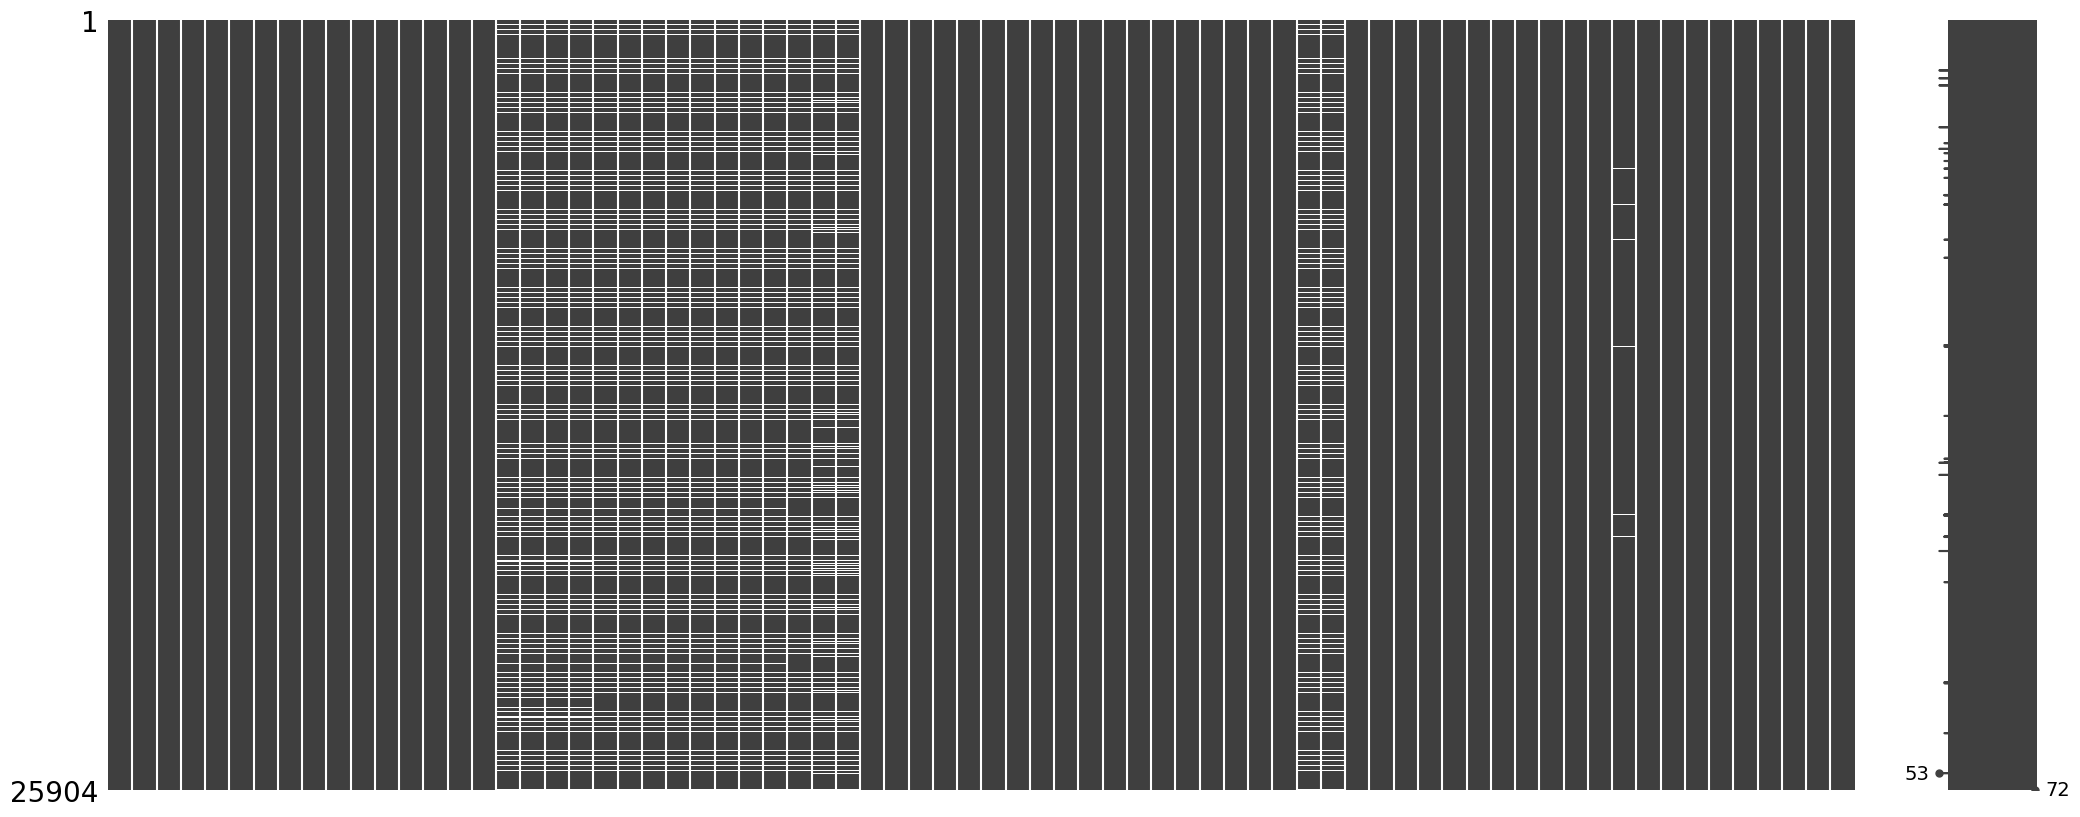

In [72]:
missingno.matrix(merged)

In [73]:
gc.collect()

0

In [74]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'lst_min', 'lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)
imputed_columns = ['lst_min', 'lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

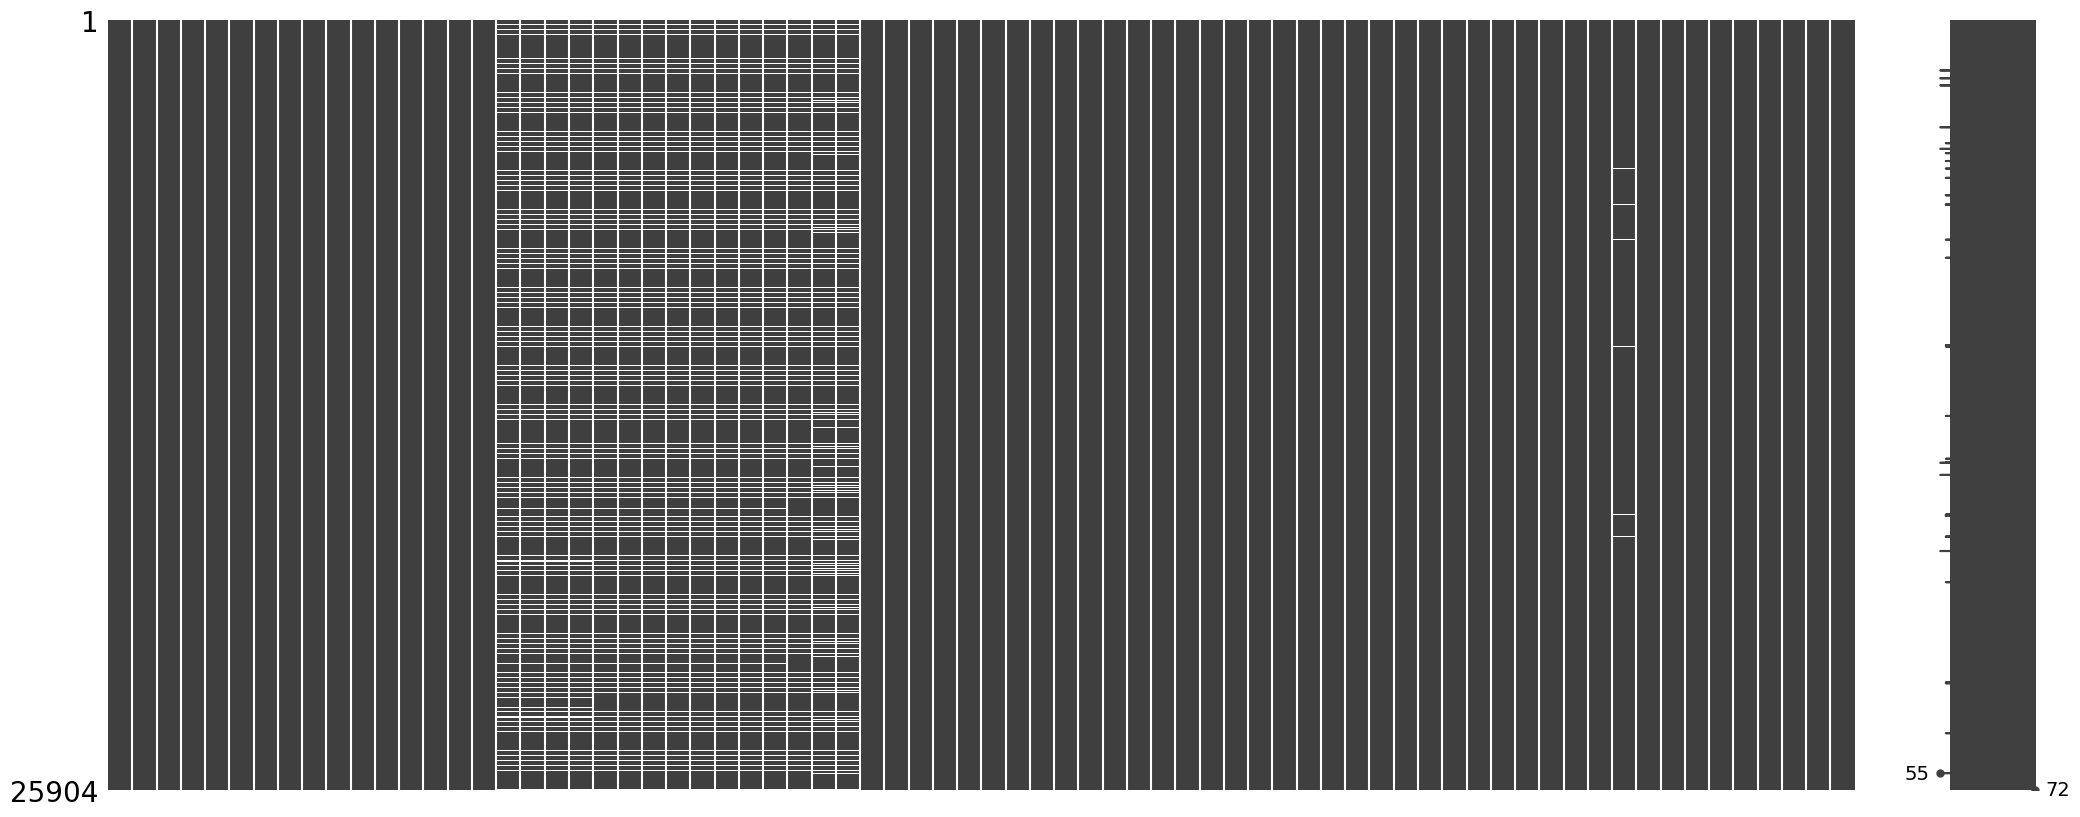

In [75]:
missingno.matrix(merged)

In [76]:
years = merged.year.unique()
years

array([2025])

In [77]:
cell_codes_un = merged.cell_number.unique()
cell_codes_un

array([   0,    1,    2, ..., 3235, 3236, 3237], dtype=int64)

In [78]:
rows = []
for year in years:
    for cell in cell_codes_un:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['cell_number'] == cell)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['rainfall_acc'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'cell_number': cell, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [79]:
biovars_df.head(20)

,cell_number,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,0,2025,10.875000,19.250000,38.500000,1142.600418,37.000000,-13.000000,50.000000,-1.166667,21.833333,21.833333,-1.166667,451.000000,191.000000,0.000000,123.927531,389.000000,0.000000,0.000000,389.000000
1,1,2025,11.125000,16.500000,39.285714,1018.665093,36.000000,-6.000000,42.000000,0.166667,21.333333,21.333333,0.166667,451.000000,191.000000,0.000000,123.927531,389.000000,0.000000,0.000000,389.000000
2,2,2025,12.437500,16.375000,39.939024,944.698554,36.000000,-5.000000,41.000000,2.666667,22.166667,22.166667,2.666667,451.000000,191.000000,0.000000,123.927531,389.000000,0.000000,0.000000,389.000000
3,3,2025,11.062500,17.625000,35.969388,1110.803281,36.000000,-13.000000,49.000000,-1.000000,21.833333,21.833333,-1.000000,451.000000,191.000000,0.000000,123.927531,389.000000,0.000000,0.000000,389.000000
4,4,2025,12.187500,17.125000,39.825581,963.600947,37.000000,-6.000000,43.000000,2.000000,22.000000,22.000000,2.000000,451.000000,191.000000,0.000000,123.927531,389.000000,0.000000,0.000000,389.000000
5,5,2025,12.250000,19.250000,42.777778,1059.986523,39.000000,-6.000000,45.000000,1.000000,22.833333,22.833333,1.000000,451.000000,191.000000,0.000000,123.927531,389.000000,0.000000,0.000000,389.000000
6,6,2025,11.312500,17.375000,37.771739,1068.355713,36.000000,-10.000000,46.000000,-0.166667,21.833333,21.833333,-0.166667,338.000000,174.000000,0.000000,136.993000,279.000000,0.000000,0.000000,279.000000
7,7,2025,11.625000,15.750000,38.414634,983.343422,35.000000,-6.000000,41.000000,1.166667,21.500000,21.500000,1.166667,338.000000,174.000000,0.000000,136.993000,279.000000,0.000000,0.000000,279.000000
8,8,2025,12.312500,15.125000,40.878378,912.585612,34.000000,-3.000000,37.000000,3.000000,21.666667,21.666667,3.000000,338.000000,174.000000,0.000000,136.993000,279.000000,0.000000,0.000000,279.000000
9,9,2025,12.187500,15.875000,40.705128,976.486961,35.000000,-4.000000,39.000000,1.833333,22.166667,22.166667,1.833333,338.000000,174.000000,0.000000,136.993000,279.000000,0.000000,0.000000,279.000000


In [80]:
merged = pd.merge(merged, biovars_df,  how='left', on=['cell_number', 'year'])

In [81]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2025) & (merged['cell_number'] == 0)]

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,0,2025-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,1,0.269888,0.628876,-0.208902,-0.628876,0.254061,0.694518,-0.157651,-0.694518,0.189705,0.113860,0.137274,0.113860,1.050645,-9.332667,-4.130000,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,4.081613,5.630000,83.839998,109.339998,126.529998,126.529998,-13.670000,2.990000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,10.875000,19.250000,38.500000,1142.600418,37.000000,-13.000000,50.000000,-1.166667,21.833333,21.833333,-1.166667,451.000000,191.000000,0.000000,123.927531,389.000000,0.000000,0.000000,389.000000
1,0,2025-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,2,0.366295,0.346762,-0.254671,-0.346762,0.261093,0.494400,-0.145091,-0.494400,0.173774,0.130960,0.128415,0.130960,-2.136667,-9.326154,-5.959583,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,2.577500,49.999999,50.419999,72.279998,198.699996,72.169998,-10.630000,1.110000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,10.875000,19.250000,38.500000,1142.600418,37.000000,-13.000000,50.000000,-1.166667,21.833333,21.833333,-1.166667,451.000000,191.000000,0.000000,123.927531,389.000000,0.000000,0.000000,389.000000
2,0,2025-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,3,0.440482,0.178383,-0.394812,-0.178383,0.378342,0.238523,-0.330627,-0.238523,0.116777,0.120771,0.085898,0.120771,9.162308,0.745789,5.187368,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,6.183871,82.639999,133.209997,175.539996,390.399991,191.699996,-0.370000,13.170000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,10.875000,19.250000,38.500000,1142.600418,37.000000,-13.000000,50.000000,-1.166667,21.833333,21.833333,-1.166667,451.000000,191.000000,0.000000,123.927531,389.000000,0.000000,0.000000,389.000000
3,0,2025-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,4,0.489129,0.187812,-0.396035,-0.187812,0.455384,0.168838,-0.349366,-0.168838,0.068506,0.113474,0.058134,0.113474,17.723333,2.630000,10.283889,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,1.931667,25.539999,30.269999,57.949999,448.349990,57.949999,-1.230000,21.150000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,10.875000,19.250000,38.500000,1142.600418,37.000000,-13.000000,50.000000,-1.166667,21.833333,21.833333,-1.166667,451.000000,191.000000,0.000000,123.927531,389.

In [82]:
df_demographics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [83]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1763,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1764,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1765,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000
1766,EL653,2023,14067.000000,71993.000000,29360.000000,115420.000000,13393.000000,67069.000000,32564.000000,113026.000000


In [84]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [85]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1763,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1764,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1765,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000
1766,EL653,2023,14067.000000,71993.000000,29360.000000,115420.000000,13393.000000,67069.000000,32564.000000,113026.000000


In [86]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

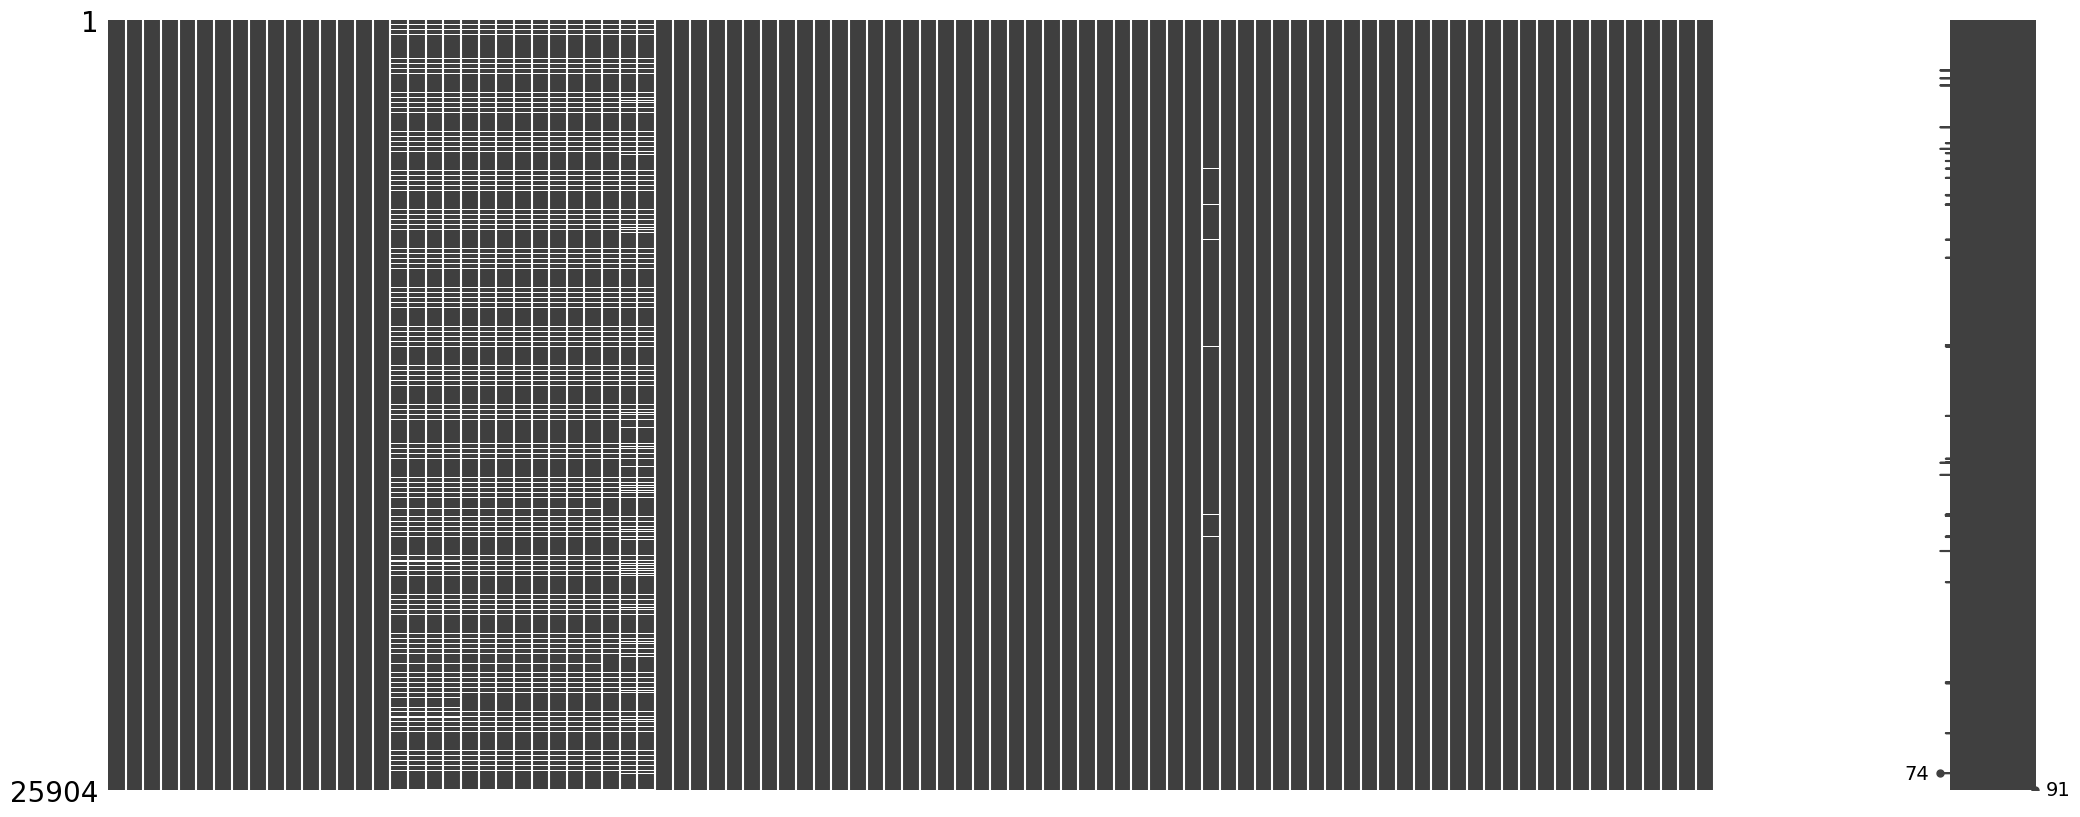

In [87]:
missingno.matrix(dataset)

In [88]:
df_economics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [89]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,9725.080000
1,EL301,2001,10452.130000
2,EL301,2002,11780.170000
3,EL301,2003,12522.310000
4,EL301,2004,13769.510000
...,...,...,...
1191,EL653,2018,3207.990000
1192,EL653,2019,3243.040000
1193,EL653,2020,2907.590000
1194,EL653,2021,3090.650000


In [90]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [91]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,9725.080000
1,EL301,2001,10452.130000
2,EL301,2002,11780.170000
3,EL301,2003,12522.310000
4,EL301,2004,13769.510000
...,...,...,...
1191,EL653,2018,3207.990000
1192,EL653,2019,3243.040000
1193,EL653,2020,2907.590000
1194,EL653,2021,3090.650000


In [92]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

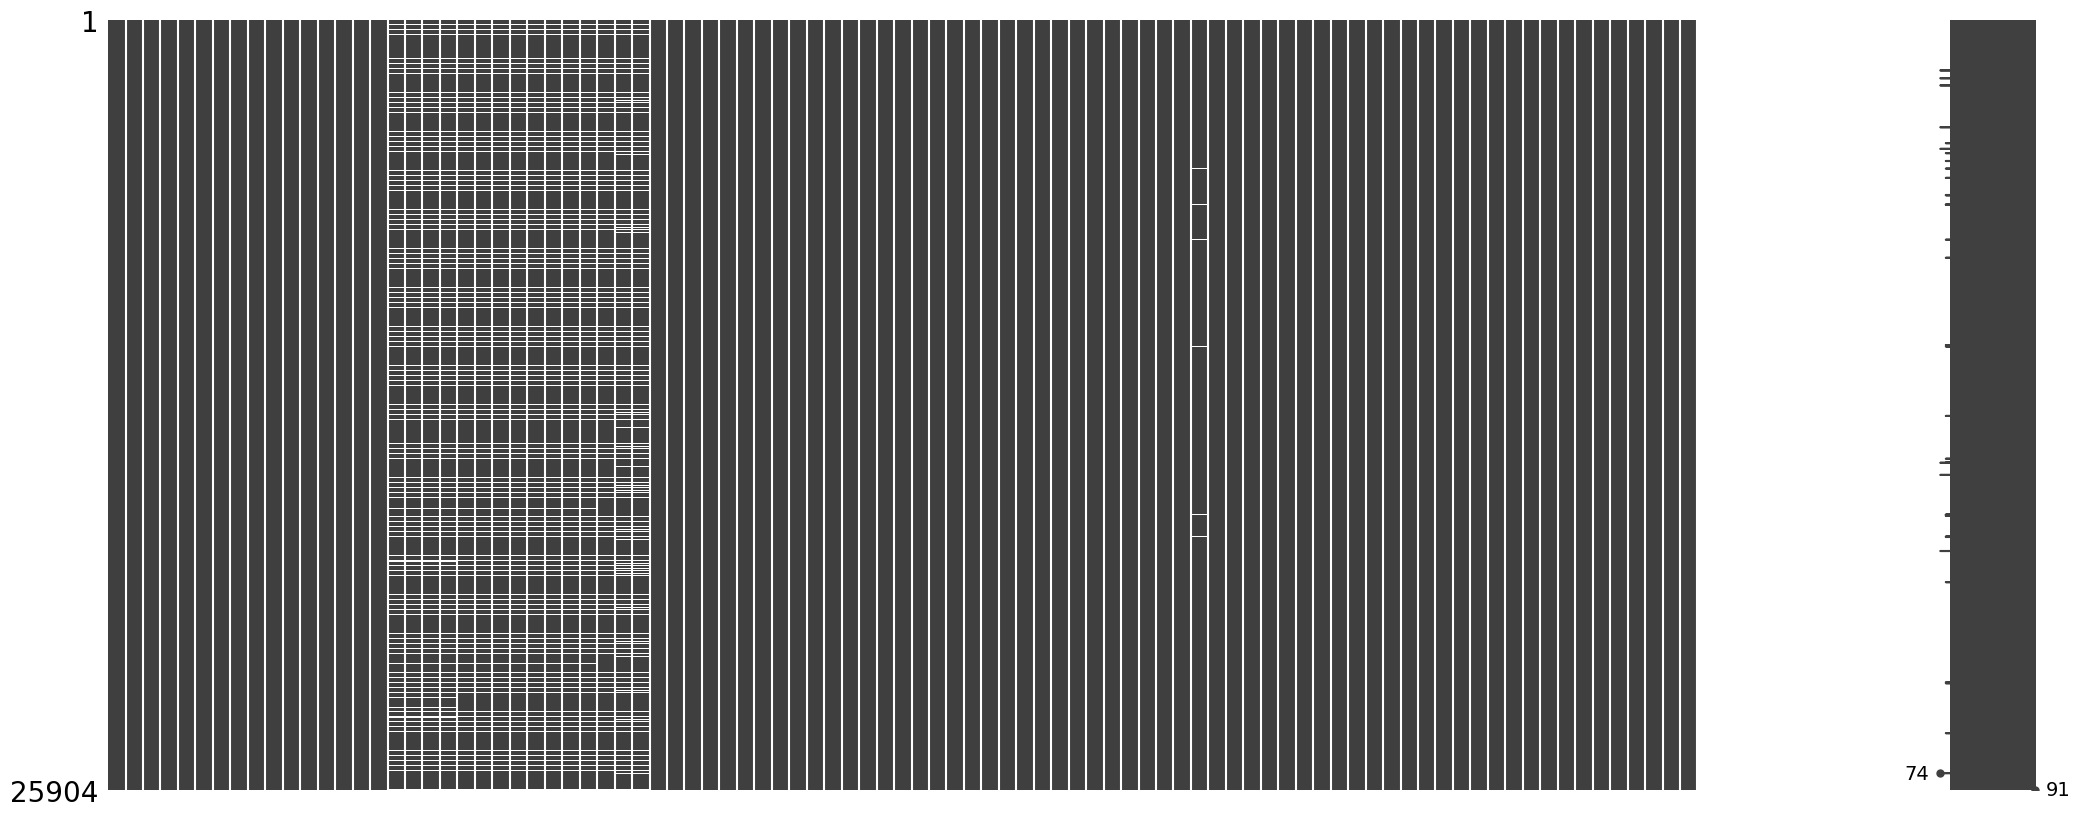

In [93]:
missingno.matrix(dataset)

In [94]:
df_trade = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 Level\Greece\data\GR_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [95]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
818,EL653,2019,3278.000000,3737.000000
819,EL653,2020,4572.000000,4962.000000
820,EL653,2021,3040.000000,3666.000000
821,EL653,2022,11830.000000,12294.000000


In [96]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [97]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
818,EL653,2019,3278.000000,3737.000000
819,EL653,2020,4572.000000,4962.000000
820,EL653,2021,3040.000000,3666.000000
821,EL653,2022,11830.000000,12294.000000


In [98]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

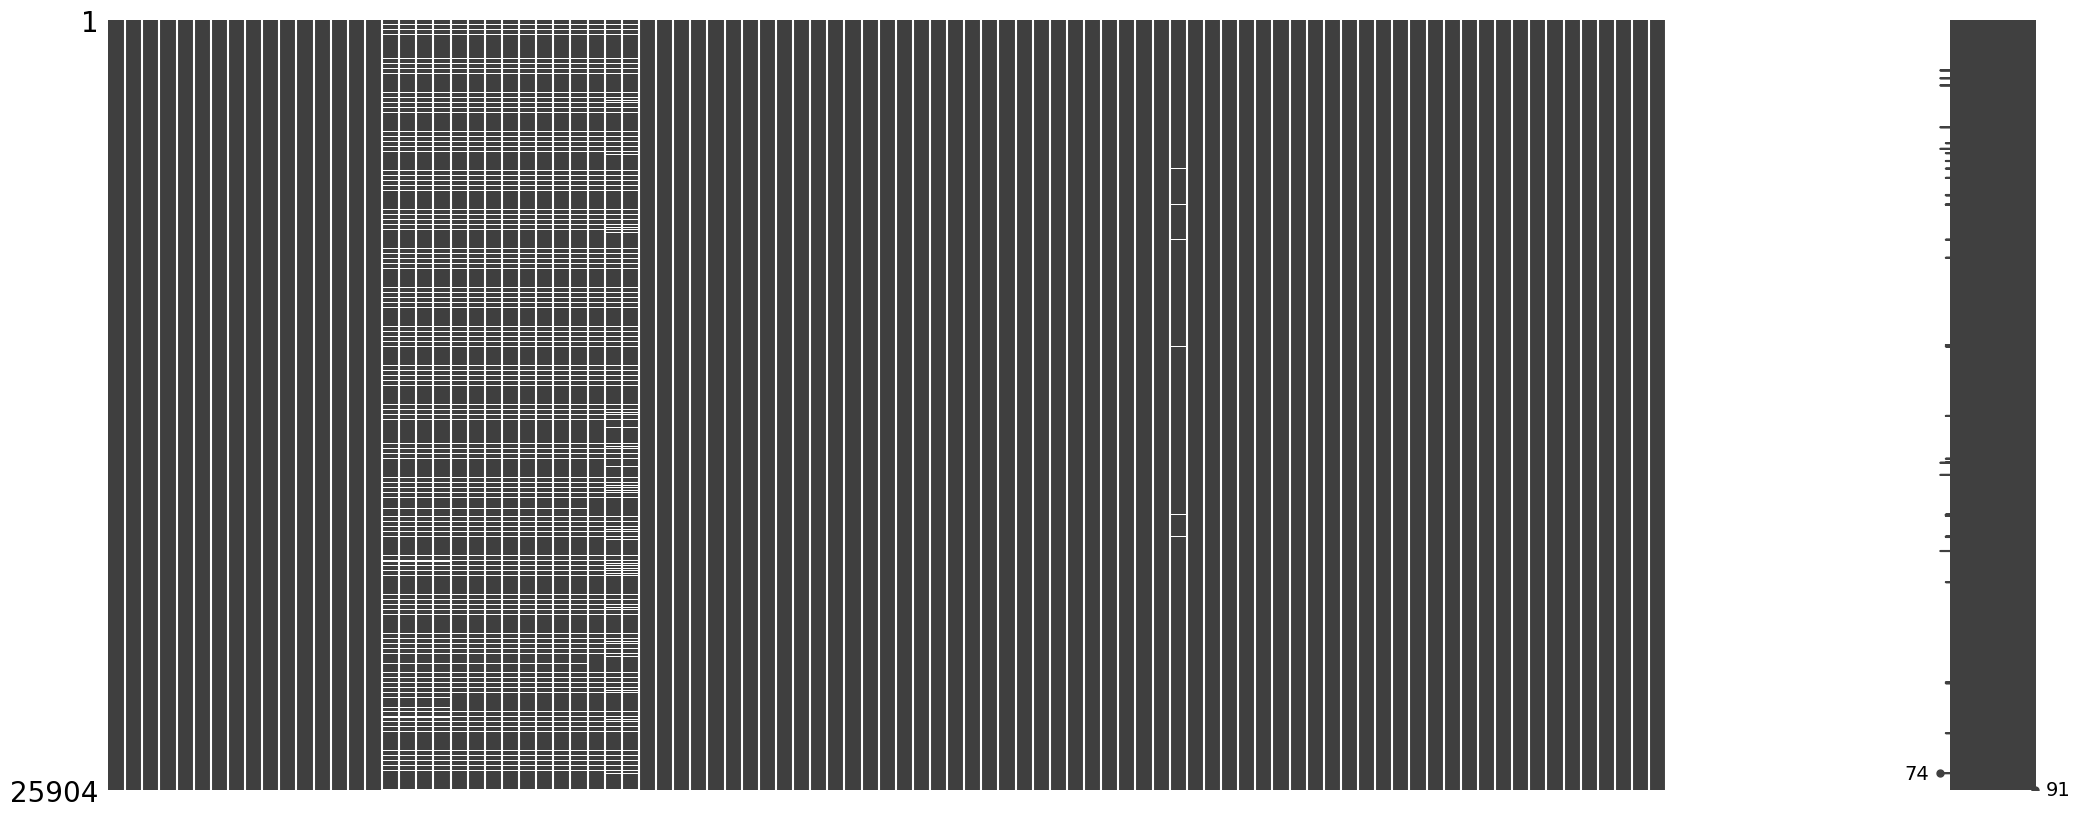

In [99]:
missingno.matrix(dataset)

In [100]:
missing = describe_dataframe(dataset, remove_zeros=True)

In [101]:
missing

,Column,Missing
16,ndvi,12.955500
17,ndmi,12.955500
18,ndwi,12.955500
19,ndbi,12.955500
20,ndvi_mean,12.631300
21,ndmi_mean,12.631300
22,ndwi_mean,12.631300
23,ndbi_mean,12.631300
24,ndvi_std,12.631300
25,ndmi_std,12.631300


In [102]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2025-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,1,0.269888,0.628876,-0.208902,-0.628876,0.254061,0.694518,-0.157651,-0.694518,0.189705,0.113860,0.137274,0.113860,1.050645,-9.332667,-4.130000,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,4.081613,5.630000,83.839998,109.339998,126.529998,126.529998,-13.670000,2.990000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,10.875000,19.250000,38.500000,1142.600418,37.000000,-13.000000,50.000000,-1.166667,21.833333,21.833333,-1.166667,451.000000,191.000000,0.000000,123.927531,389.000000,0.000000,0.000000,389.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2025-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,2,0.366295,0.346762,-0.254671,-0.346762,0.261093,0.494400,-0.145091,-0.494400,0.173774,0.130960,0.128415,0.130960,-2.136667,-9.326154,-5.959583,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,2.577500,49.999999,50.419999,72.279998,198.699996,72.169998,-10.630000,1.110000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,10.875000,19.250000,38.500000,1142.600418,37.000000,-13.000000,50.000000,-1.166667,21.833333,21.833333,-1.166667,451.000000,191.000000,0.000000,123.927531,389.000000,0.000000,0.000000,389.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2025-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,3,0.440482,0.178383,-0.394812,-0.178383,0.378342,0.238523,-0.330627,-0.238523,0.116777,0.120771,0.085898,0.120771,9.162308,0.745789,5.187368,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,6.183871,82.639999,133.209997,175.539996,390.399991,191.699996,-0.370000,13.170000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,10.875000,19.250000,38.500000,1142.600418,37.000000,-13.000000,50.000000,-1.166667,21.833333,21.833333,-1.166667,451.000000,191.000000,0.000000,123.927531,389.000000,0.000000,0.000000,389.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,2025-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,4,0.489129,0.187812,-0.396035,-0.187812,0.455384,0.168838,-0.349366,-0.168838,0.068506,0.113474,0.058134,0.113474,17.723333,2.630000,10.283889,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,1.931667,25.539999,30.269999,57.949999,448.349990,57.949999,-1.230000,21.150000,20057.653131,722.827790,34,176.440719,1574.522145,1

In [103]:
dataset.reset_index(inplace=True, drop=True)

In [104]:
# dataset['cases'].value_counts()

In [105]:
# dataset['cases'].sum()

In [106]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2025-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,1,0.269888,0.628876,-0.208902,-0.628876,0.254061,0.694518,-0.157651,-0.694518,0.189705,0.113860,0.137274,0.113860,1.050645,-9.332667,-4.130000,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,4.081613,5.630000,83.839998,109.339998,126.529998,126.529998,-13.670000,2.990000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,10.875000,19.250000,38.500000,1142.600418,37.000000,-13.000000,50.000000,-1.166667,21.833333,21.833333,-1.166667,451.000000,191.000000,0.000000,123.927531,389.000000,0.000000,0.000000,389.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2025-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,2,0.366295,0.346762,-0.254671,-0.346762,0.261093,0.494400,-0.145091,-0.494400,0.173774,0.130960,0.128415,0.130960,-2.136667,-9.326154,-5.959583,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,2.577500,49.999999,50.419999,72.279998,198.699996,72.169998,-10.630000,1.110000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,10.875000,19.250000,38.500000,1142.600418,37.000000,-13.000000,50.000000,-1.166667,21.833333,21.833333,-1.166667,451.000000,191.000000,0.000000,123.927531,389.000000,0.000000,0.000000,389.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2025-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,3,0.440482,0.178383,-0.394812,-0.178383,0.378342,0.238523,-0.330627,-0.238523,0.116777,0.120771,0.085898,0.120771,9.162308,0.745789,5.187368,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,6.183871,82.639999,133.209997,175.539996,390.399991,191.699996,-0.370000,13.170000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,30,97.000000,30,97,10,10,1,6,6,2,0,10.875000,19.250000,38.500000,1142.600418,37.000000,-13.000000,50.000000,-1.166667,21.833333,21.833333,-1.166667,451.000000,191.000000,0.000000,123.927531,389.000000,0.000000,0.000000,389.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,2025-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2025,4,0.489129,0.187812,-0.396035,-0.187812,0.455384,0.168838,-0.349366,-0.168838,0.068506,0.113474,0.058134,0.113474,17.723333,2.630000,10.283889,1.050645,-2.136667,9.162308,17.723333,-9.332667,-9.326154,0.745789,2.630000,-4.141011,-5.731410,4.954049,10.176667,1.931667,25.539999,30.269999,57.949999,448.349990,57.949999,-1.230000,21.150000,20057.653131,722.827790,34,176.440719,1574.522145,1

In [107]:
cols = dataset.columns

In [108]:
print(cols)


Index(['cell_number', 'dt_placement', 'NUTS1_ID', 'NUTS1_NAME', 'NUTS2_ID',
       'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME', 'x',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=102)


In [109]:
len(cols)

102

In [110]:
years = dataset.year.unique().tolist()

In [111]:
for item in years:
    dataset[dataset.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{item}.csv", encoding = enc, index = False)